# Analisi CST Multi-Ratio (Replica Cella 3)

Notebook per analizzare `Real.txt` e `Im.txt` con la stessa logica della cella 3, scegliendo quale parametro scansionare tra `RatioA`, `RatioB`, `RatioGap`.

## 1) Import librerie e configurazione cartella dati

In [110]:
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# ipywidgets e' opzionale: se non installato, il notebook funziona comunque.
try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

# Percorso dati
cartella = Path("SIC_e_5um/n_1")
file_re = cartella / "Real.txt"
file_im = cartella / "Im.txt"

if not cartella.exists():
    raise FileNotFoundError(f"Cartella non trovata: {cartella.resolve()}")
if not file_re.exists() or not file_im.exists():
    raise FileNotFoundError(f"File mancanti: {file_re} oppure {file_im}")

# Costanti fisiche (coerenti con logica cella 3)
beta = 0.3
Lam = 5
lambda_beta = Lam * beta
E0_const = 1.0

## 2) Parser CST unico con chiave variabile (`RatioA`, `RatioB`, `RatioGap`)

In [111]:
def parse_parameters_line(line: str):
    """Estrae i parametri dal blocco #Parameters in un dizionario {chiave: valore_float}."""
    m = re.search(r"#Parameters\s*=\s*\{(.*)\}", line)
    if not m:
        return {}

    body = m.group(1)
    params = {}
    for item in body.split(";"):
        item = item.strip()
        if not item or "=" not in item:
            continue
        k, v = item.split("=", 1)
        k = k.strip()
        v = v.strip()
        try:
            params[k] = float(v)
        except ValueError:
            continue
    return params


def parse_cst_blocks(path: Path, varying_param: str, fixed_params=None, n_target=None, tol=1e-12):
    """
    Parse file CST con blocchi ripetuti.
    Restituisce dict: blocks[var_value] = {"x": array, "y": array, "params": dict}.

    Filtri opzionali:
    - fixed_params: dict con parametri da tenere fissi (es. {"RatioB":0.5, "RatioGap":0.5})
    - n_target: armonica da selezionare
    """
    if fixed_params is None:
        fixed_params = {}

    blocks = {}
    active = False
    current_value = None
    current_x = []
    current_y = []
    current_params = None

    def flush_block():
        if active and current_value is not None and current_x:
            blocks[current_value] = {
                "x": np.array(current_x, dtype=float),
                "y": np.array(current_y, dtype=float),
                "params": current_params,
            }

    with open(path, "r", encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            if line.startswith("#Parameters"):
                flush_block()

                params = parse_parameters_line(line)
                active = True
                current_x = []
                current_y = []
                current_params = params
                current_value = None

                if varying_param not in params:
                    active = False
                    continue

                if n_target is not None:
                    n_val = params.get("n")
                    if n_val is None or abs(n_val - float(n_target)) > tol:
                        active = False
                        continue

                ok = True
                for k, v in fixed_params.items():
                    pv = params.get(k)
                    if pv is None or abs(pv - float(v)) > tol:
                        ok = False
                        break
                if not ok:
                    active = False
                    continue

                current_value = float(params[varying_param])
                continue

            if line.startswith("#"):
                continue

            if not active:
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            try:
                x_val = float(parts[0])
                y_val = float(parts[1])
            except ValueError:
                continue

            current_x.append(x_val)
            current_y.append(y_val)

    flush_block()
    return blocks

## 3) Selettore parametro da scandire (input o widget Jupyter)

In [112]:
allowed_params = ["RatioA", "RatioB", "RatioGap"]

# Selezione manuale (fallback universale)
param_name = "RatioB"
n_target = 1

# Default consigliati per fissare gli altri due parametri mentre se ne scansiona uno
scan_fixed_defaults = {
    "RatioA": {"RatioB": 0.5, "RatioGap": 0.5},
    "RatioB": {"RatioA": 0.5, "RatioGap": 0.5},
    "RatioGap": {"RatioA": 0.5, "RatioB": 0.5},
}

if param_name not in allowed_params:
    raise ValueError(f"param_name non valido: {param_name}. Opzioni: {allowed_params}")

fixed_params = dict(scan_fixed_defaults[param_name])

print(f"Parametro variabile selezionato: {param_name}")
print(f"Parametri fissi: {fixed_params}")
print(f"n_target: {n_target}")

# Widget opzionale
if HAS_WIDGETS:
    w = widgets.Dropdown(options=allowed_params, value=param_name, description="Scansione:")
    display(w)
    print("Puoi cambiare il dropdown e poi assegnare param_name = w.value prima di run_analysis().")
    print("Poi imposta fixed_params = dict(scan_fixed_defaults[param_name]).")

Parametro variabile selezionato: RatioB
Parametri fissi: {'RatioA': 0.5, 'RatioGap': 0.5}
n_target: 1


Sezione usata: y = 0 um, z = -0.0025 um
n armonica: 3
beta_sync = 0.014599
lambda_geom = 2 um
lambda_beta = 0.029198 um
lambda_p = 0.087594 um (8.759400e-08 m)
Scala campo: E_sim = 1.000e+00 V/m -> E_real = 5.000 GV/m
Fattore di scala applicato: 5.000e+09
Fase ottima = +25.502 deg
Gradiente alla fase ottima G = 1.271501e-01 GV/m
Check integrazione reale (deve ~ G): 1.271501e-01 GV/m
Numero di punti lungo x: 18


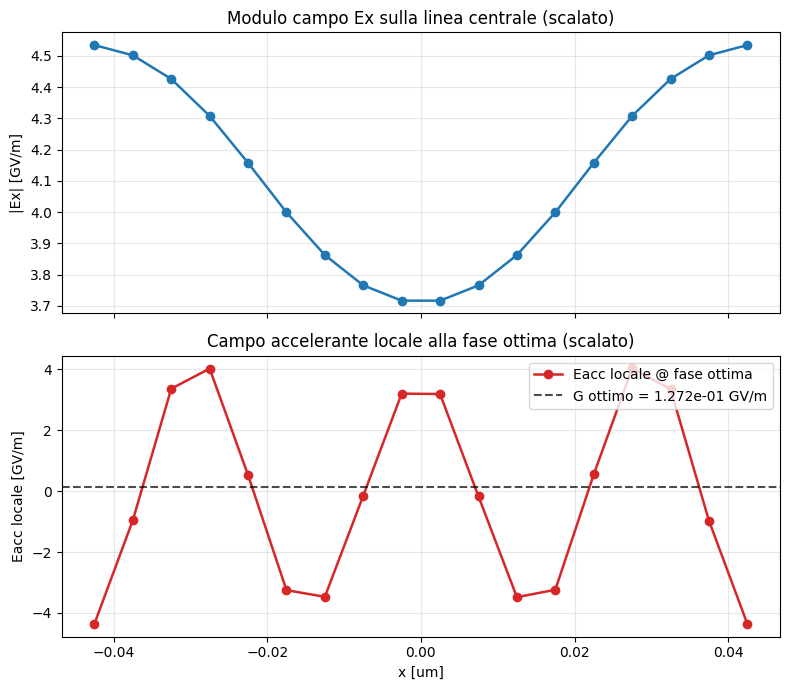

In [113]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Parametri (cella autonoma)
# =========================
file_path = Path("SiO2_P_2um/n_3/Campo.txt")
y_target_um = 0.0
z_target_um = 0.0
n_harm = 3
beta_sync = 0.014599
lambda_geom_um = 2

# Scala campo: simulazione -> campo reale
E_sim_Vpm = 1.0       # campo di riferimento usato in simulazione [V/m]
E_real_GVm = 5.0      # campo operativo desiderato [GV/m]

# Conversioni unita'
um_to_m = 1e-6
to_GVm = 1e-9         # V/m -> GV/m
E_real_Vpm = E_real_GVm * 1e9
field_scale = E_real_Vpm / E_sim_Vpm

# Colonne attese nel file esportato da CST
cols = ["x_um", "y_um", "z_um", "ExRe", "ExIm", "EyRe", "EyIm", "EzRe", "EzIm"]

# La prima riga contiene header testuale, la seconda e' una linea di separazione.
df = pd.read_csv(
    file_path,
    sep=r"\s+",
    engine="python",
    skiprows=2,
    names=cols,
)

# Selezione del centro canale: y = y_target_um e z = z_target_um (valore piu' vicino disponibile)
y_center = df["y_um"].iloc[(df["y_um"] - y_target_um).abs().argmin()]
df_y = df[np.isclose(df["y_um"], y_center)]

z_center = df_y["z_um"].iloc[(df_y["z_um"] - z_target_um).abs().argmin()]
line = df_y[np.isclose(df_y["z_um"], z_center)].sort_values("x_um").copy()

# Campo complesso Ex sulla linea centrale, scalato al campo operativo reale
Ex_raw = line["ExRe"].to_numpy() + 1j * line["ExIm"].to_numpy()  # [V/m] per E_sim_Vpm
Ex = Ex_raw * field_scale                                           # [V/m] per E_real_GVm
x_um = line["x_um"].to_numpy()

if len(x_um) < 2:
    raise ValueError("Troppi pochi punti lungo x per calcolare il gradiente.")

# Parametri di sincronismo definiti localmente (nessuna dipendenza da altre celle)
lambda_beta_um = lambda_geom_um * beta_sync
lambda_p_um = n_harm * lambda_beta_um

# Conversione esplicita in SI per il calcolo del gradiente
x_m = x_um * um_to_m
lambda_p_m = lambda_p_um * um_to_m

# Stessa formula delle altre celle: media di Ex * exp(-i*2*pi*n*x/lambda_p)
phase_sync = np.exp(-1j * 2 * np.pi * n_harm * x_m / lambda_p_m)
L_m = x_m[-1] - x_m[0]
complex_grad = np.trapezoid(Ex * phase_sync, x_m) / L_m  # [V/m]

# Gradiente accelerante massimo (fase ottima)
G_best = np.abs(complex_grad)  # [V/m]
phi_best_rad = -np.angle(complex_grad)
phi_best_deg = np.degrees(phi_best_rad)

# Profilo locale del campo accelerante alla fase ottima
Eacc_best_x = np.real(Ex * phase_sync * np.exp(1j * phi_best_rad))  # [V/m]
G_check = np.trapezoid(Eacc_best_x, x_m) / L_m  # [V/m]

# Conversione in GV/m
Ex_abs_GVm = np.abs(Ex) * to_GVm
Eacc_best_x_GVm = Eacc_best_x * to_GVm
G_best_GVm = G_best * to_GVm
G_check_GVm = G_check * to_GVm

print(f"Sezione usata: y = {y_center:.6g} um, z = {z_center:.6g} um")
print(f"n armonica: {n_harm}")
print(f"beta_sync = {beta_sync:.6g}")
print(f"lambda_geom = {lambda_geom_um:.6g} um")
print(f"lambda_beta = {lambda_beta_um:.6g} um")
print(f"lambda_p = {lambda_p_um:.6g} um ({lambda_p_m:.6e} m)")
print(f"Scala campo: E_sim = {E_sim_Vpm:.3e} V/m -> E_real = {E_real_GVm:.3f} GV/m")
print(f"Fattore di scala applicato: {field_scale:.3e}")
print(f"Fase ottima = {phi_best_deg:+.3f} deg")
print(f"Gradiente alla fase ottima G = {G_best_GVm:.6e} GV/m")
print(f"Check integrazione reale (deve ~ G): {G_check_GVm:.6e} GV/m")
print(f"Numero di punti lungo x: {len(x_um)}")

fig, ax = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

ax[0].plot(x_um, Ex_abs_GVm, marker='o', lw=1.8)
ax[0].set_ylabel("|Ex| [GV/m]")
ax[0].set_title("Modulo campo Ex sulla linea centrale (scalato)")
ax[0].grid(True, alpha=0.3)

ax[1].plot(x_um, Eacc_best_x_GVm, color="tab:red", marker='o', lw=1.8, label="Eacc locale @ fase ottima")
ax[1].axhline(G_best_GVm, ls="--", color="k", alpha=0.7, label=f"G ottimo = {G_best_GVm:.3e} GV/m")
ax[1].set_xlabel("x [um]")
ax[1].set_ylabel("Eacc locale [GV/m]")
ax[1].set_title("Campo accelerante locale alla fase ottima (scalato)")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

## 4-8) Allineamento, calcolo, tabella, grafici e funzione unica `run_analysis(param_name)`

Riepilogo risultati:
RatioB=0.100  G=2.682692e-02  eta_E0=2.682692e-02  Emax=7.135022e-01  eta_Emax=3.759894e-02  phi=-151.61 deg
RatioB=0.200  G=4.124141e-02  eta_E0=4.124141e-02  Emax=6.744504e-01  eta_Emax=6.114817e-02  phi=-154.34 deg
RatioB=0.300  G=4.789260e-02  eta_E0=4.789260e-02  Emax=6.600133e-01  eta_Emax=7.256309e-02  phi=-153.90 deg
RatioB=0.400  G=5.184274e-02  eta_E0=5.184274e-02  Emax=6.719123e-01  eta_Emax=7.715701e-02  phi=-152.37 deg
RatioB=0.500  G=5.643991e-02  eta_E0=5.643991e-02  Emax=7.224918e-01  eta_Emax=7.811841e-02  phi=-151.68 deg
RatioB=0.600  G=6.240715e-02  eta_E0=6.240715e-02  Emax=8.038093e-01  eta_Emax=7.763924e-02  phi=-153.53 deg
RatioB=0.700  G=6.963081e-02  eta_E0=6.963081e-02  Emax=9.102458e-01  eta_Emax=7.649671e-02  phi=-159.71 deg
RatioB=0.800  G=7.439438e-02  eta_E0=7.439438e-02  Emax=9.877902e-01  eta_Emax=7.531395e-02  phi=-169.96 deg
RatioB=0.900  G=7.356574e-02  eta_E0=7.356574e-02  Emax=9.897138e-01  eta_Emax=7.433032e-02  phi=+178.63 de

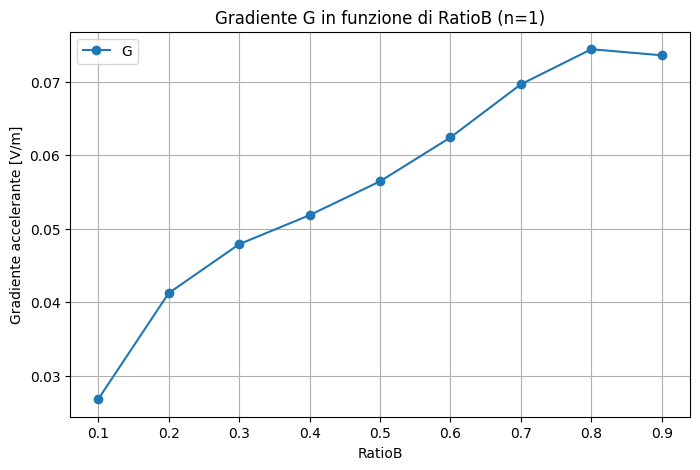

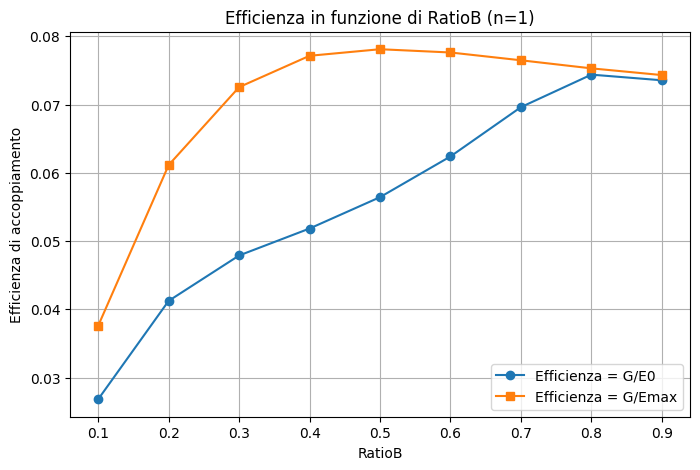

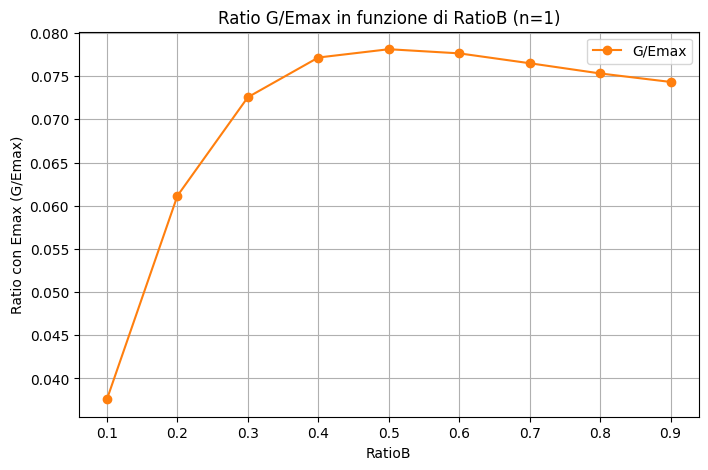

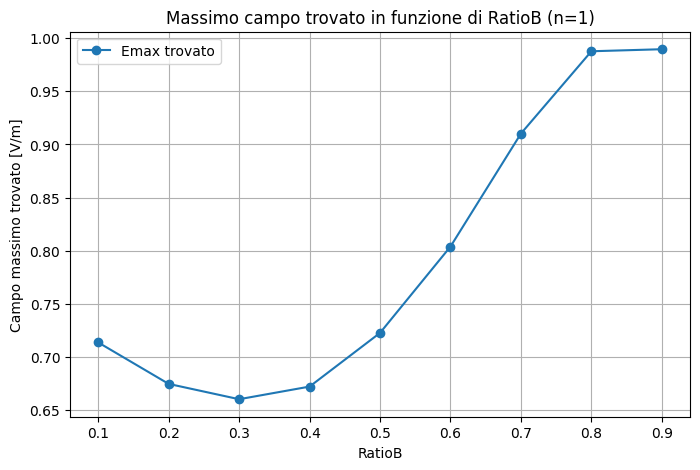

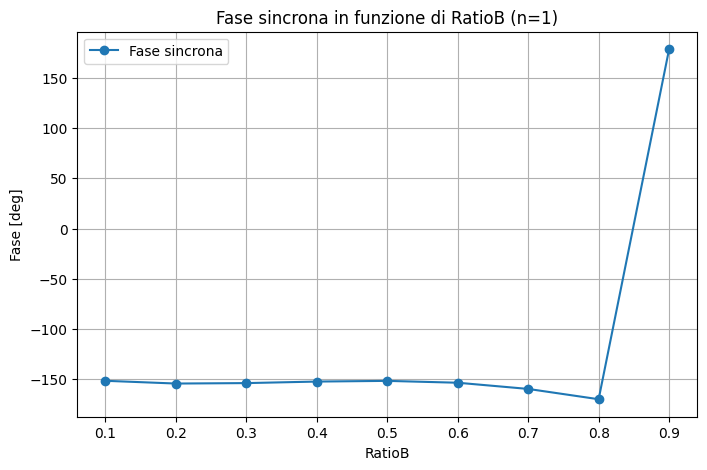

In [114]:
def run_analysis(param_name: str, fixed_params=None, n_target=3, tol=1e-12):
    """Pipeline completa: parse, allineamento, calcolo metriche, tabella e grafici."""
    allowed = ["RatioA", "RatioB", "RatioGap"]
    if param_name not in allowed:
        raise ValueError(f"param_name non valido: {param_name}. Opzioni: {allowed}")

    if fixed_params is None:
        scan_fixed_defaults = {
            "RatioA": {"RatioB": 0.5, "RatioGap": 0.5},
            "RatioB": {"RatioA": 0.5, "RatioGap": 0.5},
            "RatioGap": {"RatioA": 0.5, "RatioB": 0.5},
        }
        fixed_params = dict(scan_fixed_defaults[param_name])

    blocks_re = parse_cst_blocks(
        file_re,
        varying_param=param_name,
        fixed_params=fixed_params,
        n_target=n_target,
        tol=tol,
    )
    blocks_im = parse_cst_blocks(
        file_im,
        varying_param=param_name,
        fixed_params=fixed_params,
        n_target=n_target,
        tol=tol,
    )

    common_values = sorted(set(blocks_re.keys()) & set(blocks_im.keys()))
    if not common_values:
        raise ValueError(
            "Nessun valore comune tra Real/Im con i filtri scelti. "
            f"param_name={param_name}, fixed_params={fixed_params}, n_target={n_target}"
        )

    n_harm = int(n_target)
    lambda_p = n_harm * lambda_beta

    G = np.zeros(len(common_values))
    eta_E0 = np.zeros(len(common_values))
    eta_Emax = np.zeros(len(common_values))
    E_max = np.zeros(len(common_values))
    phi_rad = np.zeros(len(common_values))
    phi_deg = np.zeros(len(common_values))

    for i, val in enumerate(common_values):
        x_re = blocks_re[val]["x"]
        x_im = blocks_im[val]["x"]
        y_re = blocks_re[val]["y"]
        y_im = blocks_im[val]["y"]

        if len(x_re) != len(x_im) or np.max(np.abs(x_re - x_im)) > tol:
            raise ValueError(f"Asse x non allineato per {param_name}={val}")

        x = x_re
        Ex = y_re + 1j * y_im

        phase = np.exp(-1j * 2 * np.pi * n_harm * x / lambda_p)
        L = x[-1] - x[0]
        complex_grad = np.trapezoid(Ex * phase, x) / L

        G[i] = np.abs(complex_grad)
        phi_rad[i] = np.angle(complex_grad)
        phi_deg[i] = np.degrees(phi_rad[i])

        E_max[i] = np.max(np.abs(Ex))
        eta_E0[i] = G[i] / E0_const
        eta_Emax[i] = G[i] / E_max[i]

    # Tabella risultati ordinata
    rows = []
    for i, val in enumerate(common_values):
        rows.append(
            {
                param_name: float(val),
                "G": float(G[i]),
                "phi_deg": float(phi_deg[i]),
                "E_max": float(E_max[i]),
                "eta_E0": float(eta_E0[i]),
                "eta_Emax": float(eta_Emax[i]),
            }
        )

    print("Riepilogo risultati:")
    for r in rows:
        print(
            f"{param_name}={r[param_name]:.3f}  "
            f"G={r['G']:.6e}  "
            f"eta_E0={r['eta_E0']:.6e}  "
            f"Emax={r['E_max']:.6e}  "
            f"eta_Emax={r['eta_Emax']:.6e}  "
            f"phi={r['phi_deg']:+.2f} deg"
        )

    # Grafico 1: G
    plt.figure(figsize=(8, 5))
    plt.plot(common_values, G, marker="o", label="G")
    plt.xlabel(param_name)
    plt.ylabel("Gradiente accelerante [V/m]")
    plt.title(f"Gradiente G in funzione di {param_name} (n={n_harm})")
    plt.grid(True)
    plt.legend()
    plt.savefig(cartella / f"{param_name}_G_vs_{param_name}_n{n_harm}.png")
    plt.show()

    # Grafico 2: Efficienze
    plt.figure(figsize=(8, 5))
    plt.plot(common_values, eta_E0, marker="o", label="Efficienza = G/E0")
    plt.plot(common_values, eta_Emax, marker="s", label="Efficienza = G/Emax")
    plt.xlabel(param_name)
    plt.ylabel("Efficienza di accoppiamento")
    plt.title(f"Efficienza in funzione di {param_name} (n={n_harm})")
    plt.grid(True)
    plt.legend()
    plt.savefig(cartella / f"{param_name}_efficiency_vs_{param_name}_n{n_harm}.png")
    plt.show()

    # Grafico 3: solo G/Emax
    plt.figure(figsize=(8, 5))
    plt.plot(common_values, eta_Emax, marker="o", color="tab:orange", label="G/Emax")
    plt.xlabel(param_name)
    plt.ylabel("Ratio con Emax (G/Emax)")
    plt.title(f"Ratio G/Emax in funzione di {param_name} (n={n_harm})")
    plt.grid(True)
    plt.legend()
    plt.savefig(cartella / f"{param_name}_ratio_Emax_vs_{param_name}_n{n_harm}.png")
    plt.show()

    # Grafico 4: Emax
    plt.figure(figsize=(8, 5))
    plt.plot(common_values, E_max, marker="o", label="Emax trovato")
    plt.xlabel(param_name)
    plt.ylabel("Campo massimo trovato [V/m]")
    plt.title(f"Massimo campo trovato in funzione di {param_name} (n={n_harm})")
    plt.grid(True)
    plt.legend()
   # plt.savefig(cartella / f"{param_name}_Emax_vs_{param_name}_n{n_harm}.png")
    plt.show()

    # Grafico 5: fase
    plt.figure(figsize=(8, 5))
    plt.plot(common_values, phi_deg, marker="o", label="Fase sincrona")
    plt.xlabel(param_name)
    plt.ylabel("Fase [deg]")
    plt.title(f"Fase sincrona in funzione di {param_name} (n={n_harm})")
    plt.grid(True)
    plt.legend()
    #plt.savefig(cartella / f"{param_name}_phi_vs_{param_name}_n{n_harm}.png")
    plt.show()

    return {
        "param_name": param_name,
        "fixed_params": fixed_params,
        "n_target": n_harm,
        "x": np.array(common_values, dtype=float),
        "G": G,
        "eta_E0": eta_E0,
        "eta_Emax": eta_Emax,
        "E_max": E_max,
        "phi_deg": phi_deg,
        "rows": rows,
    }


# Esempio rapido di esecuzione
result = run_analysis(param_name=param_name, fixed_params=fixed_params, n_target=n_target)